In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("StudentPerformanceFactors.csv")
print(df.head())
df.columns


   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Access  Tutoring_Sessions Family_Income Teacher_Quality  \
0             Ye

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='str')

In [92]:
num_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Exam_Score']

null_teacher_rows = df[df['Teacher_Quality'].isnull()]
# df['Teacher_Quality'].fillna(df['Teacher_Quality'].mode()[0],inplace=True)
df.fillna({'Teacher_Quality': df['Teacher_Quality'].mode()[0]}, inplace=True)

print(df.isnull().sum())




Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality                0
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [93]:

df.fillna({'Parental_Education_Level': df['Parental_Education_Level'].mode()[0]}, inplace=True)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68


In [94]:
df.isnull().sum()
# df['Distance_from_Home'].fillna(df['Distance_from_Home'].mean(), inplace=True)
# df['Distance_from_Home']=df['Distance_from_Home'].fillna(df['Distance_from_Home'].mean(), inplace=True)
# সঠিক পদ্ধতি
# df['Distance_from_Home'] = df['Distance_from_Home'].fillna(df['Distance_from_Home'].mean())


Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality                0
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level       0
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [95]:
mode_value = df['Distance_from_Home'].mode()[0]
df['Distance_from_Home'] = df['Distance_from_Home'].fillna(mode_value)
print(df.isnull().sum())

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64


In [96]:

# df.insert(0,'student_id',range(1,1+len(df)),inplace=True)
df.to_csv('clean_student_data.csv', index=False)
df.to_json('clean_student_data.json', orient='records' )
df.to_excel('clean_student_data.xlsx', index=False)
print("Data exported successfully to CSV, JSON, and Excel formats.")

Data exported successfully to CSV, JSON, and Excel formats.


Exam_Score
97     3
98     3
99     2
100    1
101    1
Name: Hours_Studied, dtype: int64


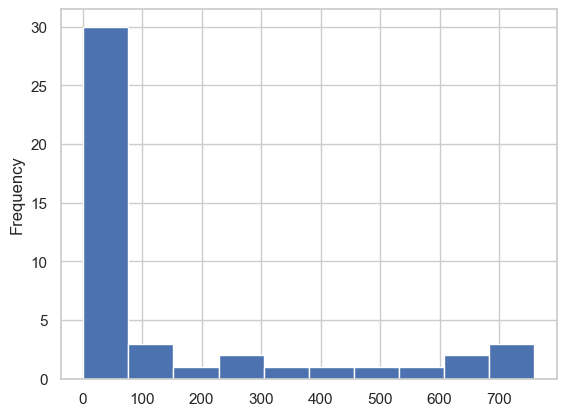

In [97]:
hour_studied = df.groupby(['Exam_Score'])['Hours_Studied'].count()
print(hour_studied.tail())
hour_studied.plot(kind="hist", bins=10)
plt.show()

Hours_Studied
1       3
2       6
3      12
4      17
5      21
6      17
7      51
8      58
9      86
10     94
11    146
12    192
13    218
14    269
15    315
16    351
17    381
18    401
19    441
20    465
21    431
22    402
23    411
24    357
25    289
26    263
27    229
28    171
29    134
30    123
31     77
32     54
33     40
34     29
35     20
36     11
37      6
38      7
39      7
43      1
44      1
Name: Sleep_Hours, dtype: int64


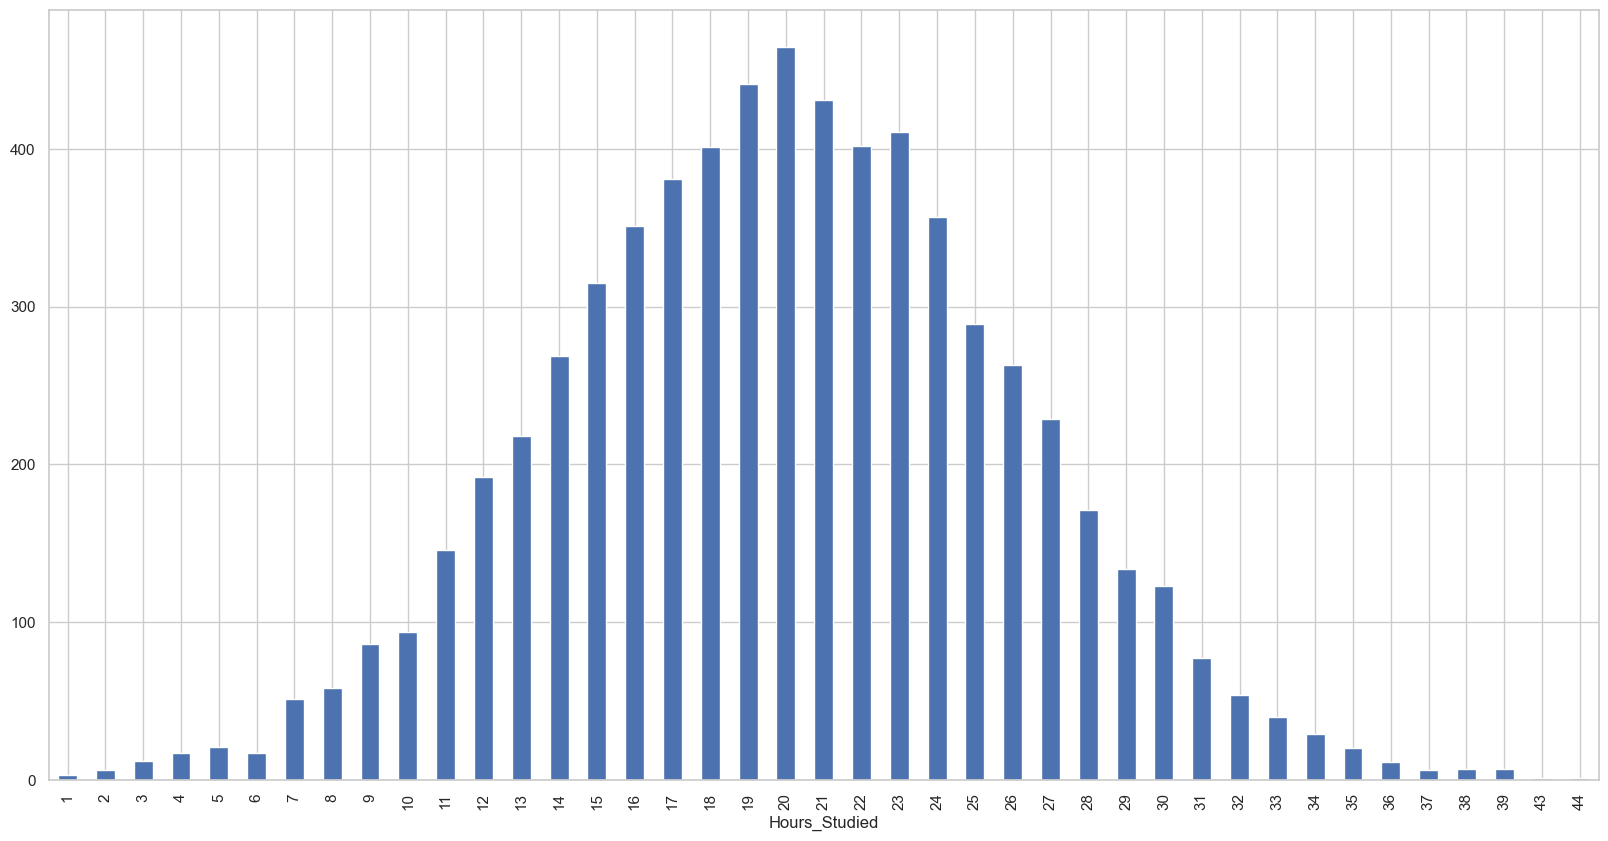

In [98]:
hour_studied= df.groupby('Hours_Studied')['Sleep_Hours'].count()
print(hour_studied)
plt.figure(figsize=(20,10))
hour_studied.plot(kind="bar")
plt.show()


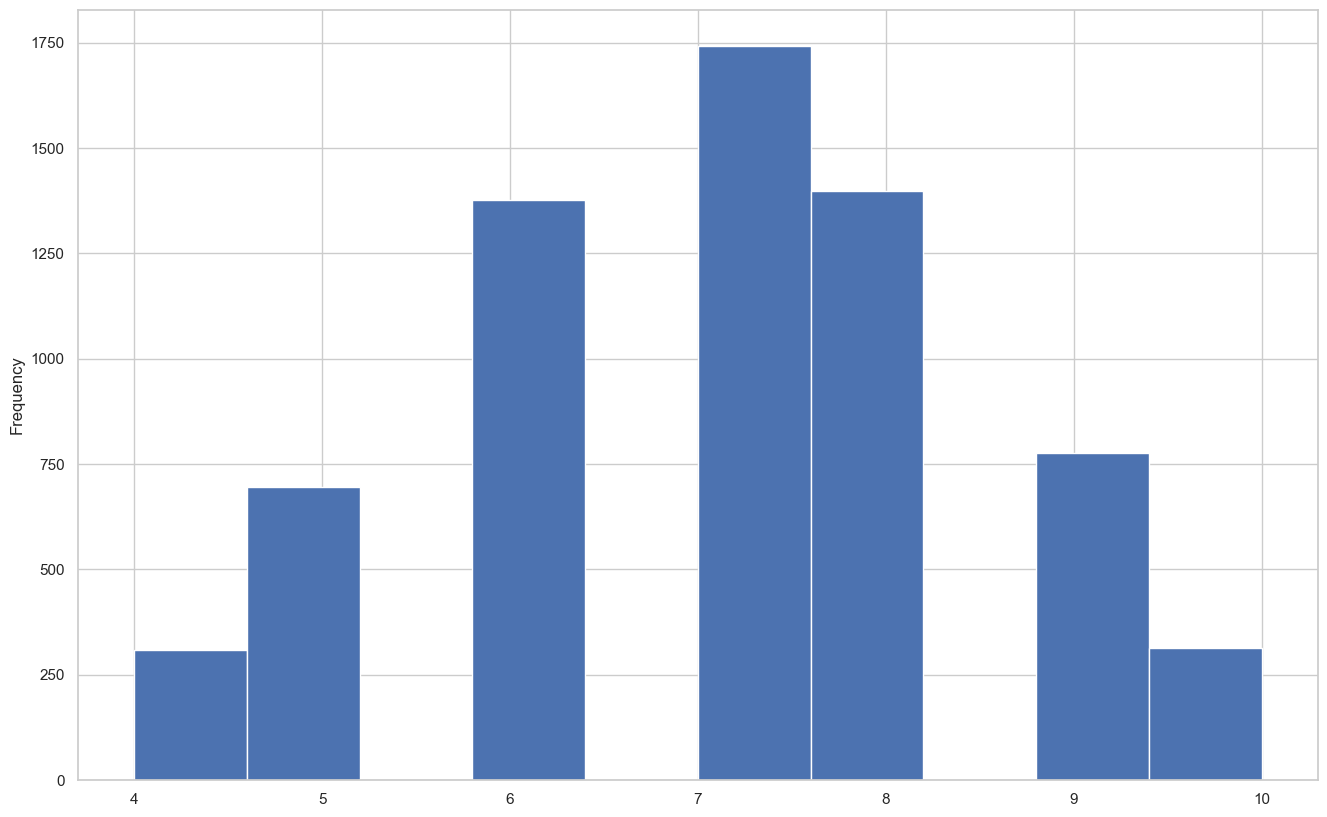

In [99]:
plt.figure(figsize=(16,10))
df["Sleep_Hours"].plot(kind="hist",bins=10)
plt.show()

In [100]:
School_Type = df.groupby('School_Type')['Exam_Score'].count()
# print(School_Type)
# plt.figure(figsize=(10,10))
# School_Type.plot(kind="pie",autopct="%1.1f%%")
# plt.title("Distribution of Exam Scores by School Type")
# fig, ax =plt.subplots(figsize=(10,10))
# ax[0].pie(School_Type, labels=School_Type.index, autopct="%1.1f%%")
# ax[0].set_title("Distribution of Exam Scores by School Type")

# ax[1].bar(School_Type.index,School_Type.values)
# ax[1].set_title("Distribution of Exam Scores by School Type")
# ax[1].set_xlabel("School Type")
# ax[1].set_ylabel("Number of Students")
# plt.tight_layout()

# plt.show()

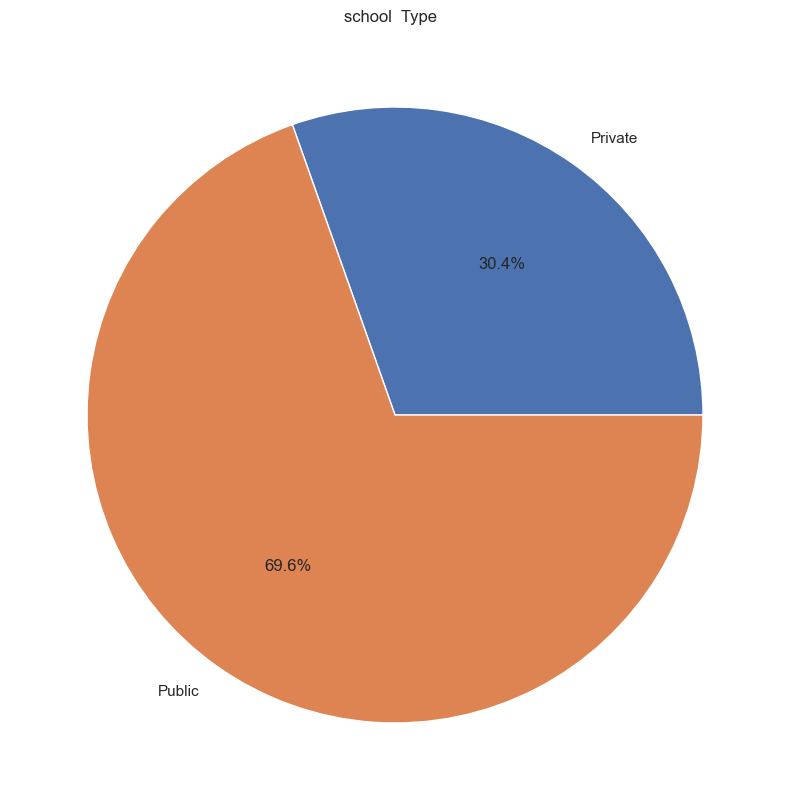

In [101]:
school_type=df.groupby('School_Type')['Exam_Score'].count()
plt.figure(figsize=(10,10))
school_type.plot(kind="pie",autopct="%1.1f%%")
plt.title("school  Type  ")
plt.savefig("school_type_pie_chart.png")
plt.show()

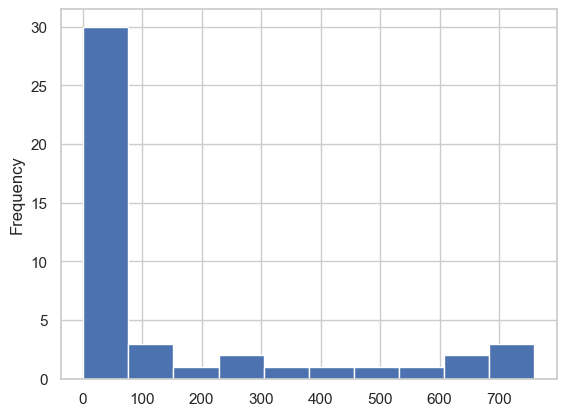

Exam_Score
55       1
56       1
57       4
58      22
59      40
60      77
61     171
62     264
63     371
64     501
65     679
66     751
67     717
68     759
69     624
70     542
71     408
72     304
73     141
74     106
75      48
76      16
77       5
78       4
79       3
80       5
82       4
83       1
84       3
85       1
86       4
87       2
88       3
89       3
91       1
92       2
93       2
94       4
95       2
96       1
97       3
98       3
99       2
100      1
101      1
Name: Parental_Education_Level, dtype: int64


In [102]:
# df.info()
data =df.groupby(['Exam_Score'])['Parental_Education_Level'].count()
data.plot(kind="hist", bins=10)
plt.savefig("Exam_Score_histogram.png")
plt.show()
print(data)

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='str')


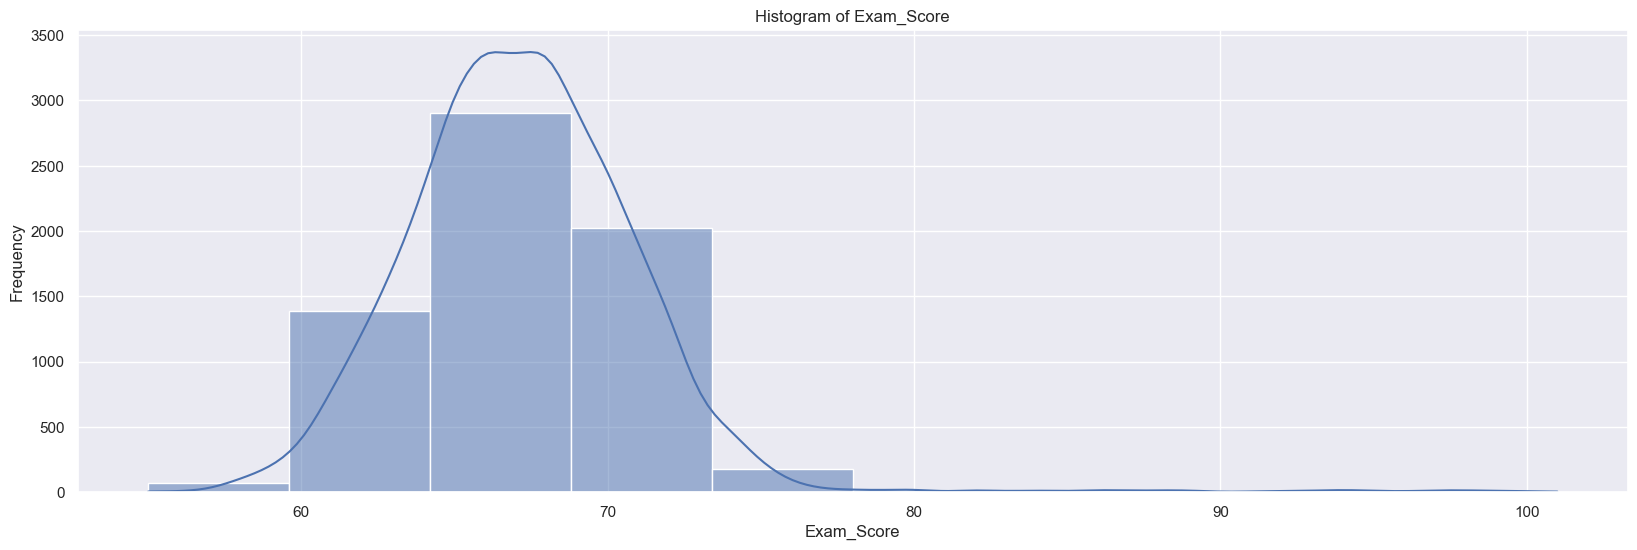

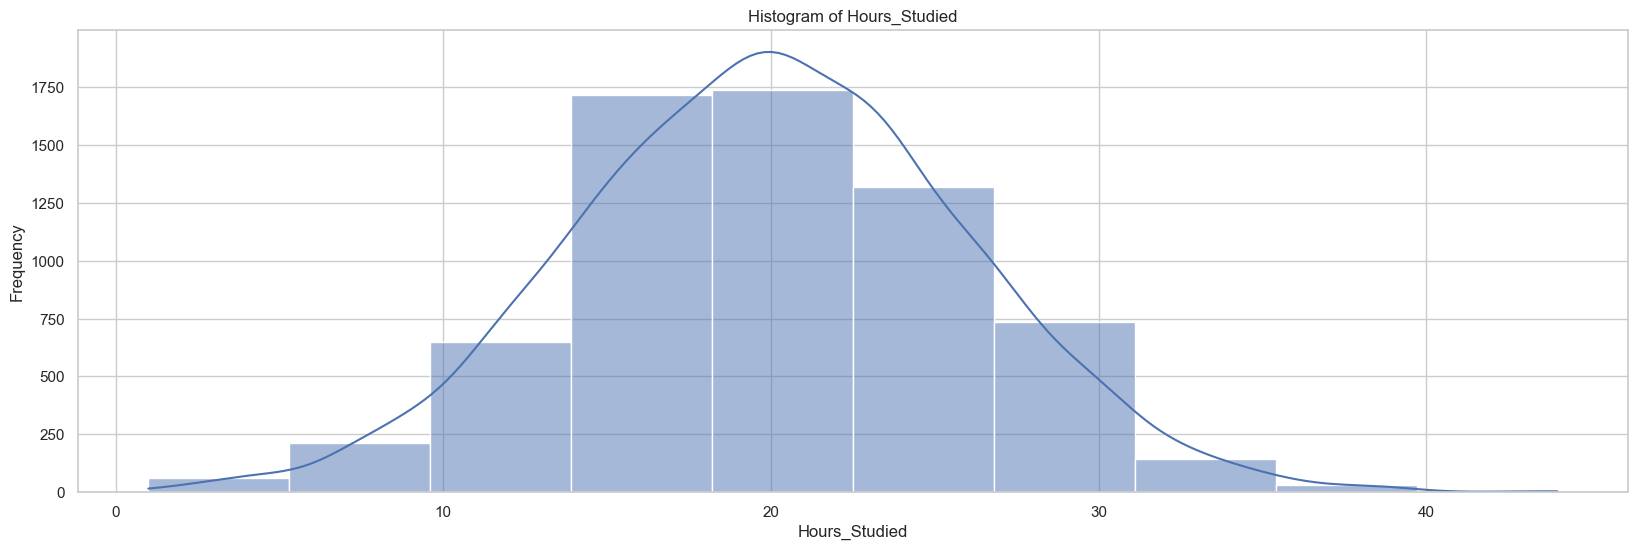

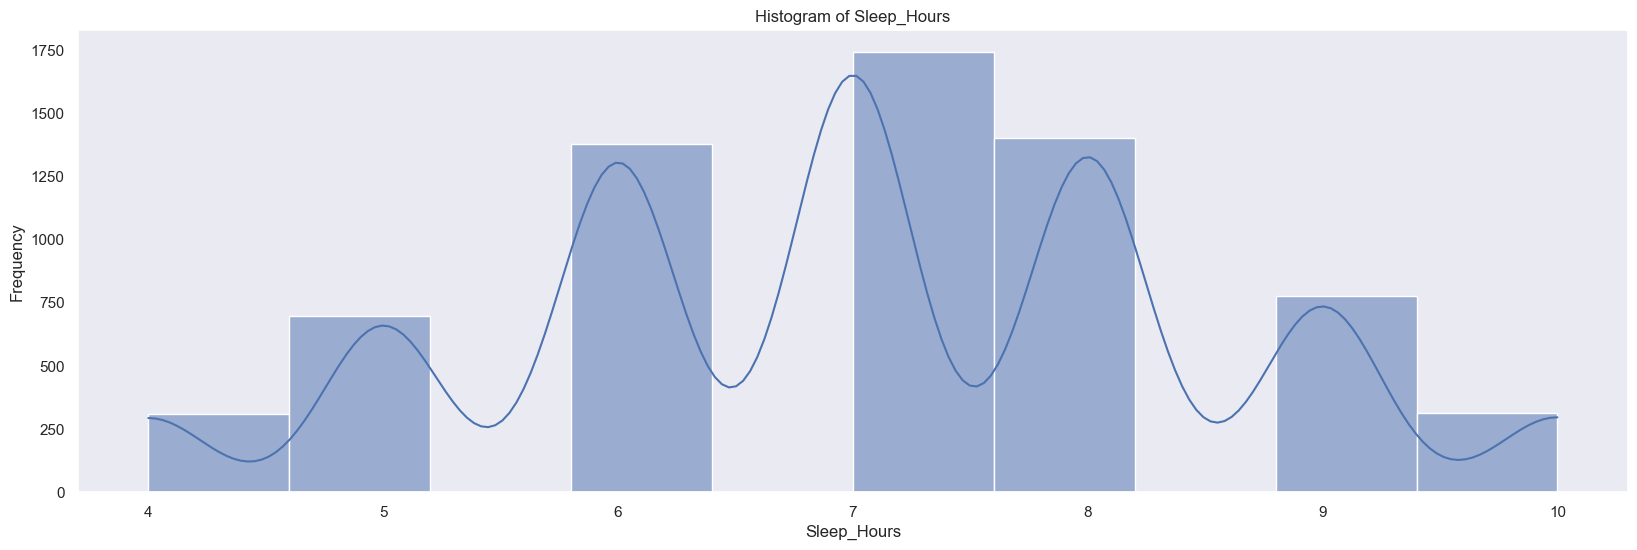

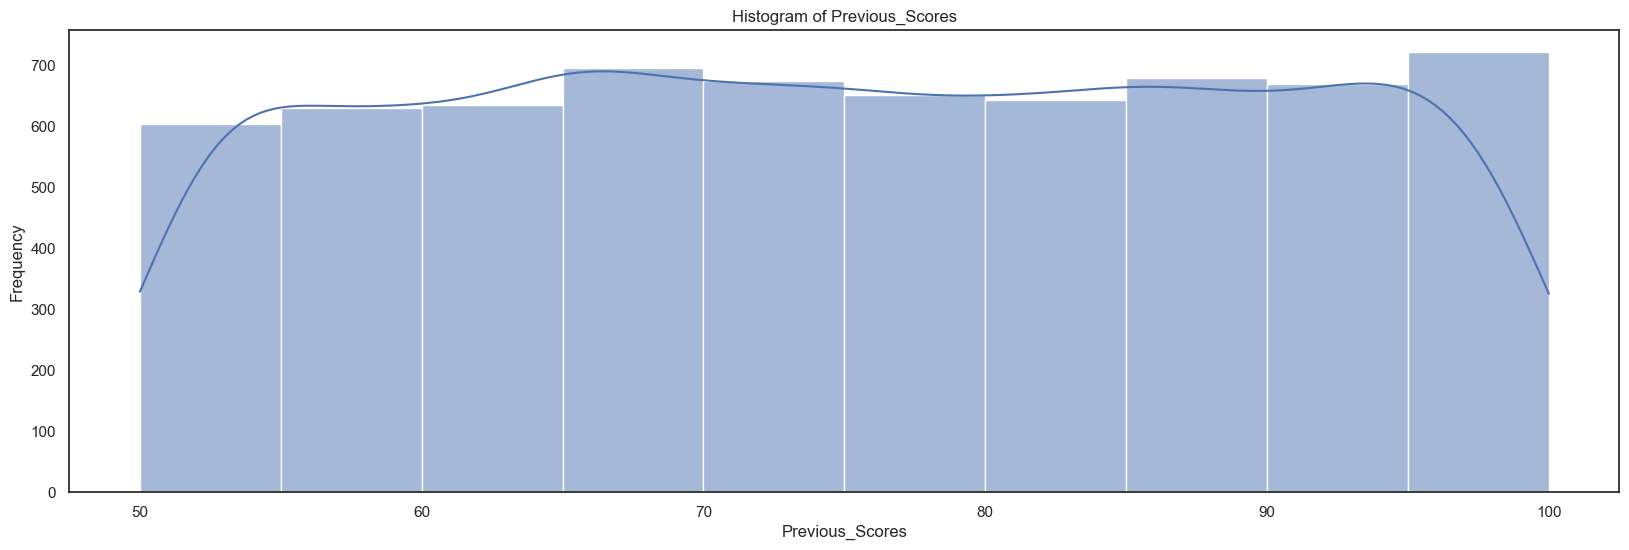

In [103]:

print(df.select_dtypes(include=['number']).columns)
columns = ["Exam_Score", "Hours_Studied", "Sleep_Hours", "Previous_Scores","Physical_Activity","Tutoring_Sessions"]
styles = ["darkgrid", "whitegrid", "dark", "white"]

for col,style in zip(columns,styles):
    sns.set_style(style)
    plt.figure(figsize=(20, 6))
    sns.histplot(df[col],bins=10, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


In [104]:
df[["Exam_Score", "Hours_Studied", "Sleep_Hours", "Previous_Scores"]]
filtered_df = df[df["Previous_Scores"] > 90].value_counts()
print(filtered_df.head(10))

Hours_Studied  Attendance  Parental_Involvement  Access_to_Resources  Extracurricular_Activities  Sleep_Hours  Previous_Scores  Motivation_Level  Internet_Access  Tutoring_Sessions  Family_Income  Teacher_Quality  School_Type  Peer_Influence  Physical_Activity  Learning_Disabilities  Parental_Education_Level  Distance_from_Home  Gender  Exam_Score
24             98          Medium                Medium               Yes                         7            91               Medium            Yes              2                  Medium         Medium           Public       Neutral         4                  No                     Postgraduate              Near                Male    74            1
29             89          Low                   Medium               Yes                         8            98               Medium            Yes              1                  Medium         Medium           Public       Negative        4                  No                     High Schoo

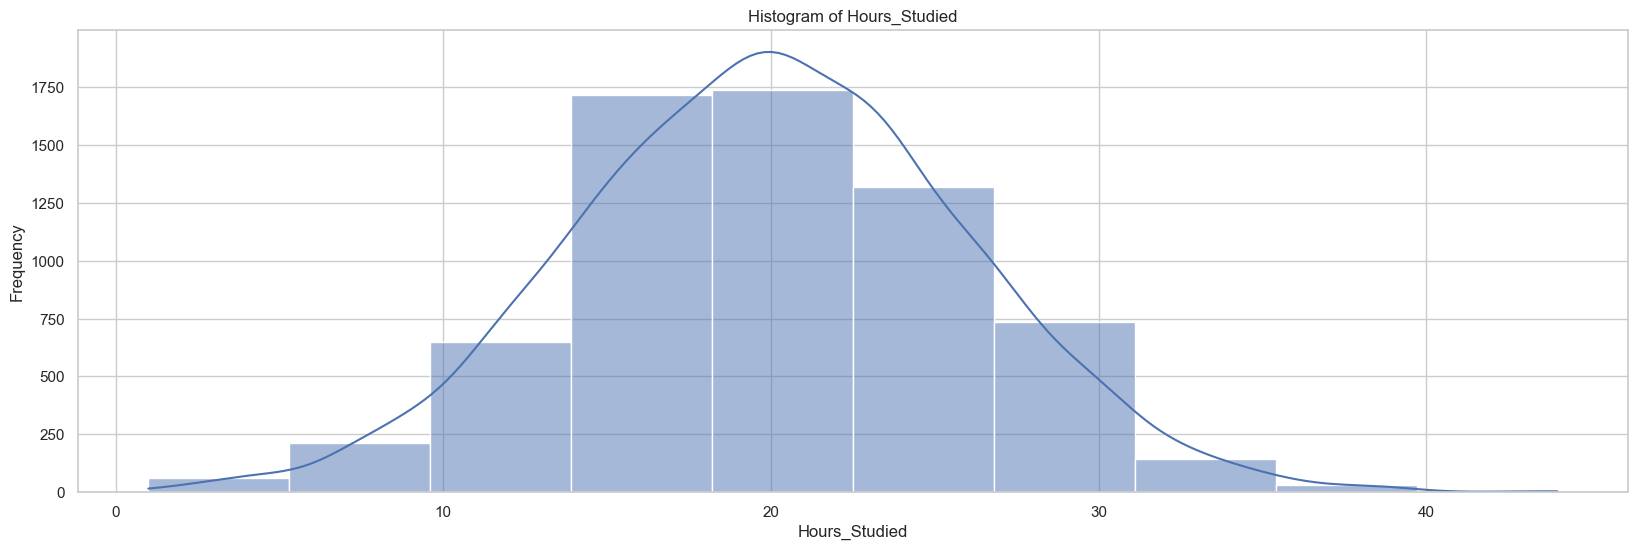

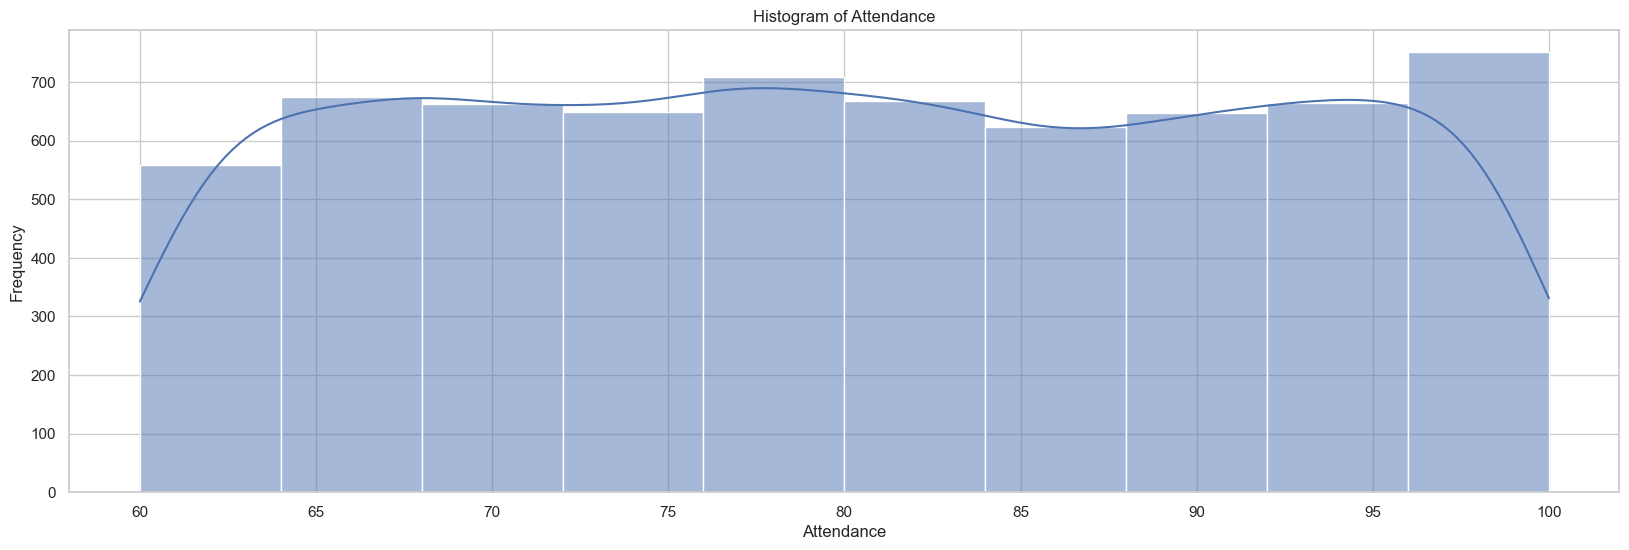

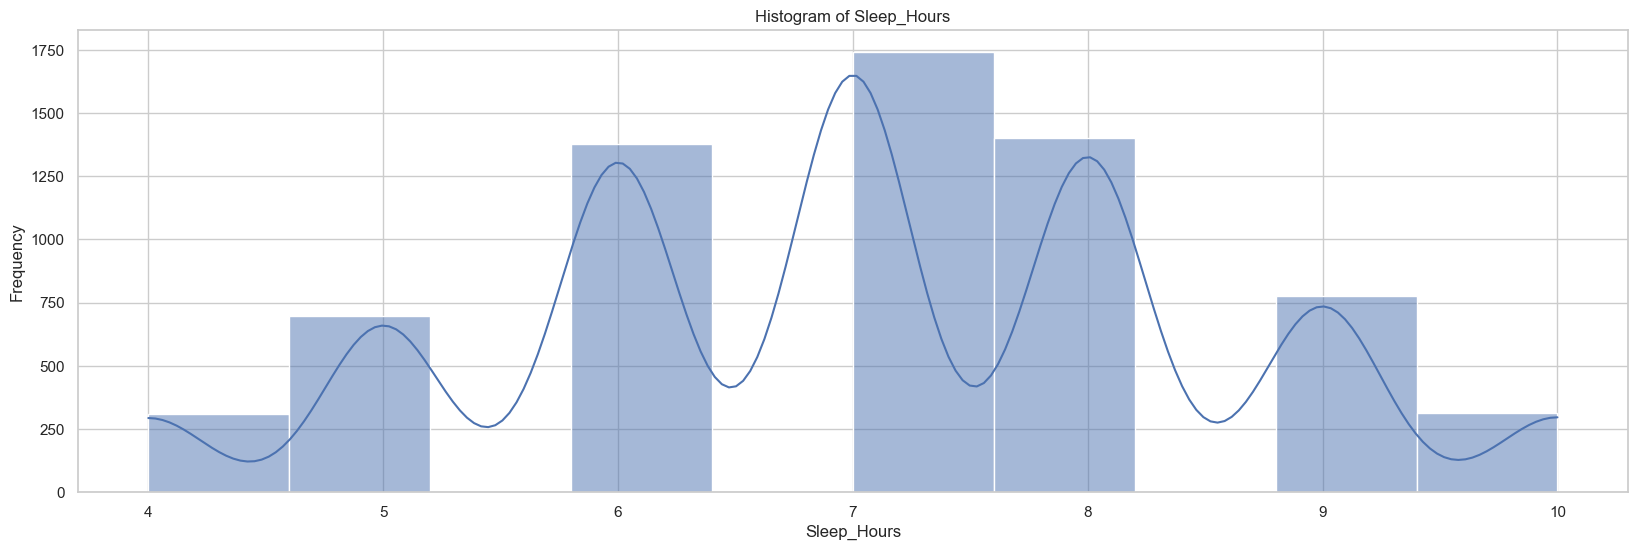

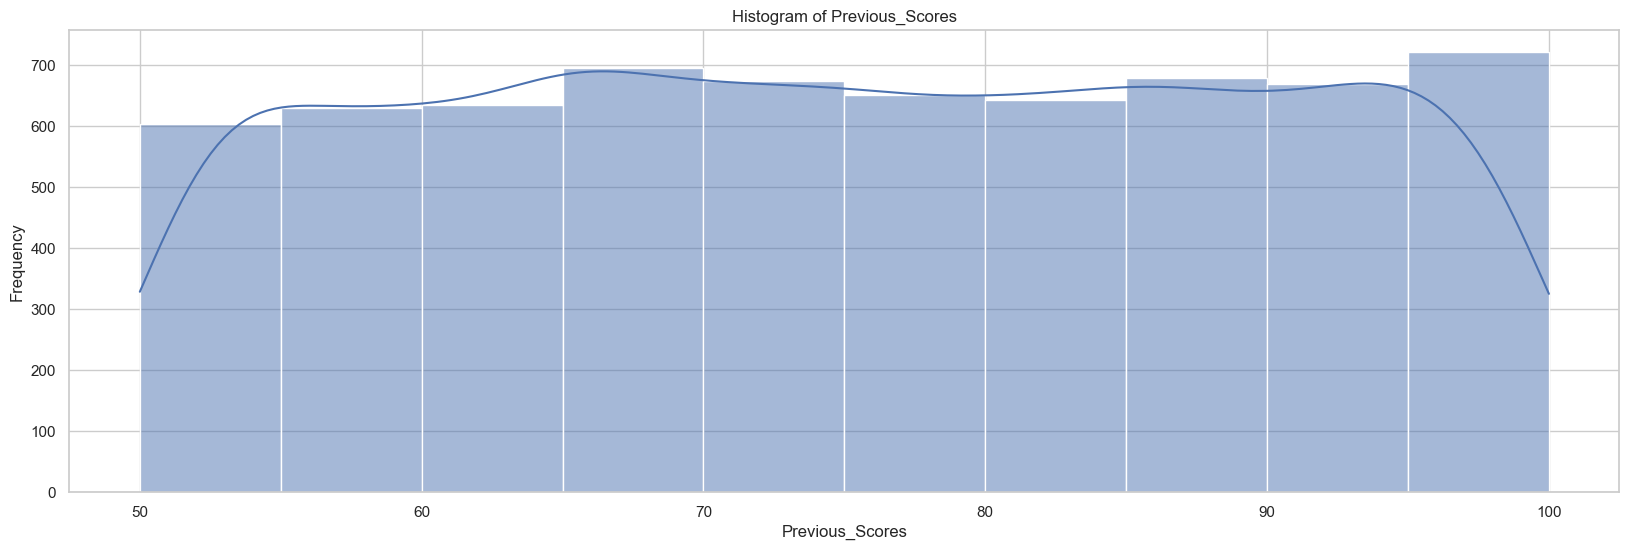

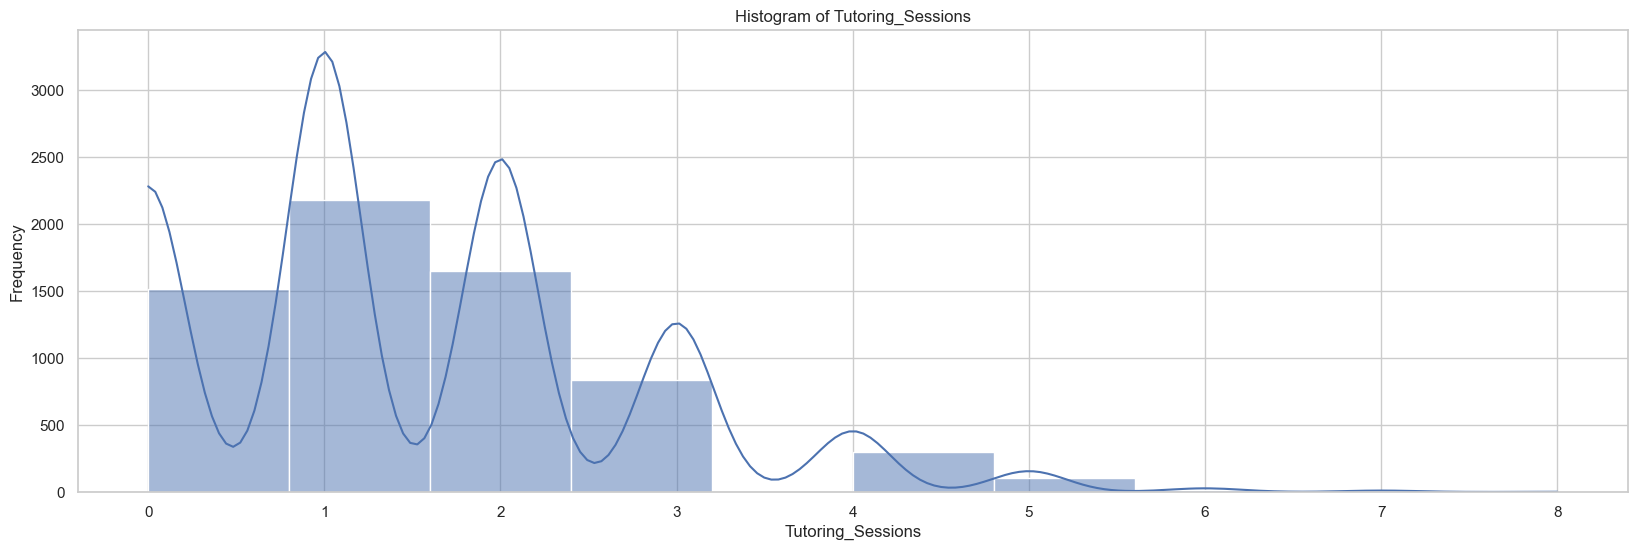

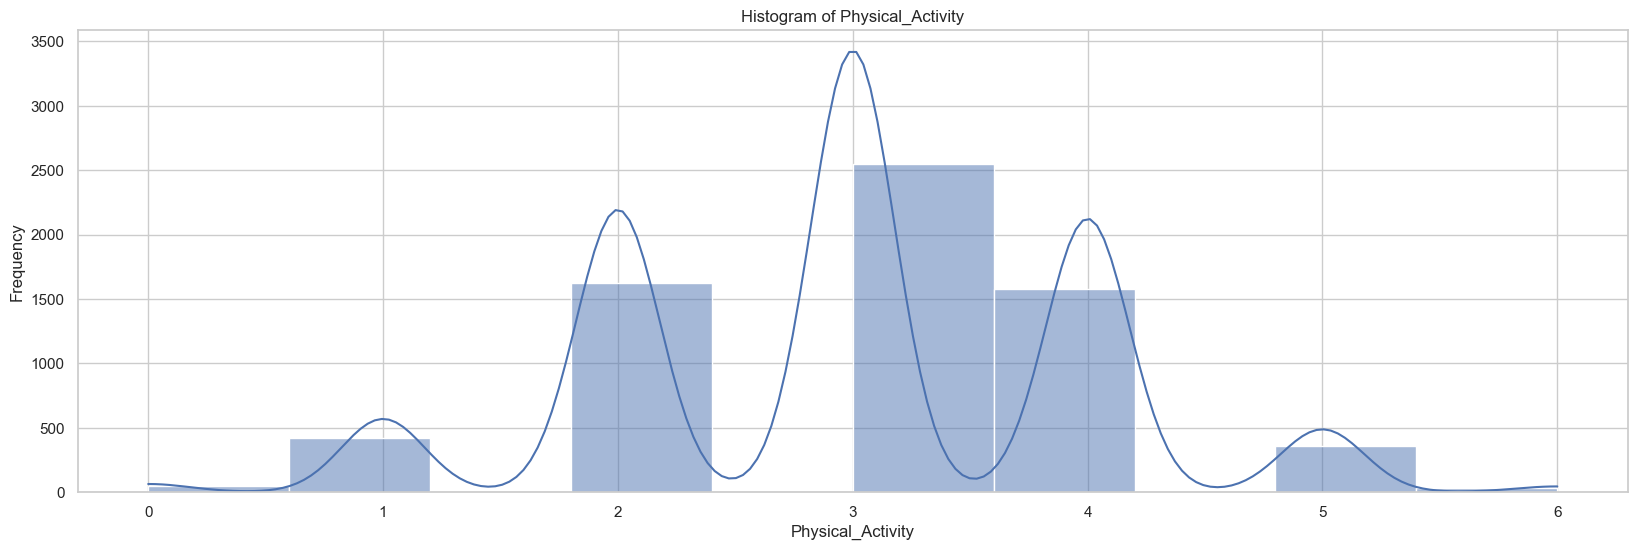

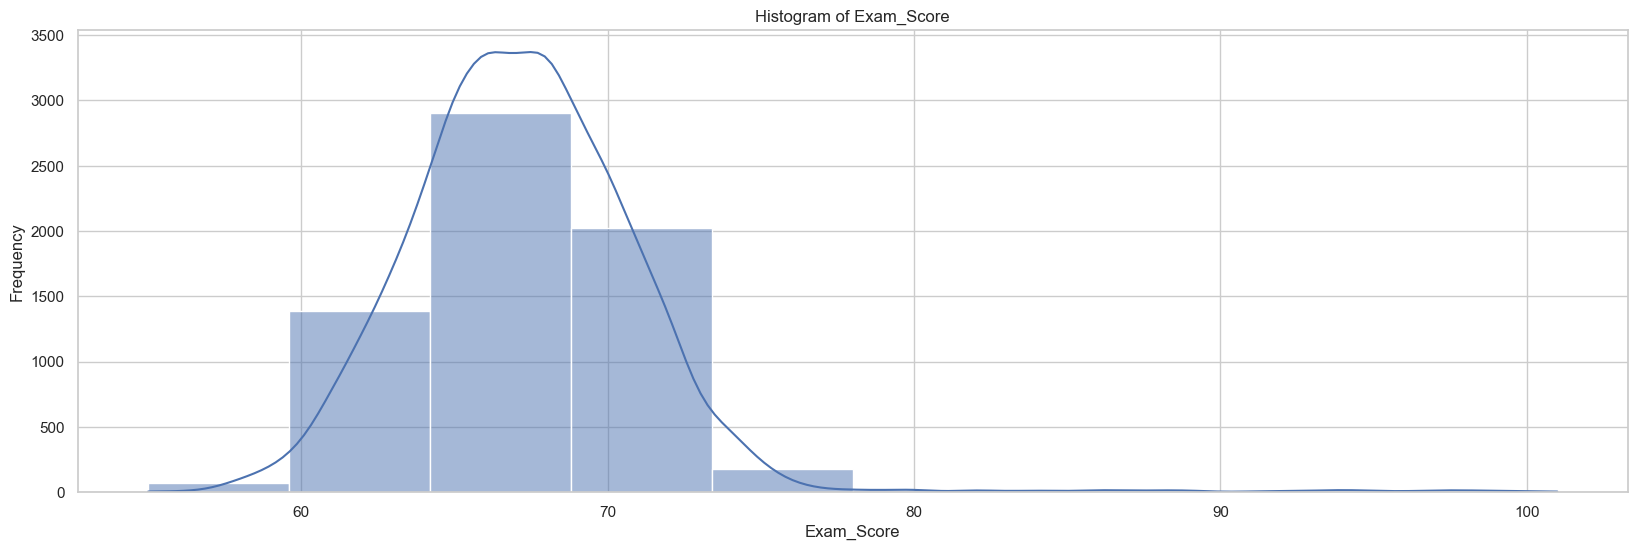

In [105]:
# df.select_dtypes(include=['number']).columns
for col in df.select_dtypes(include=['number']).columns:
    sns.set_style("whitegrid")
    plt.figure(figsize=(20, 6))
    sns.histplot(df[col], bins=10, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    # plt.show()
    # plt.savefig(f"{col}_histogram.png")
    plt.savefig(f"{col}_histogram.png", dpi=300, bbox_inches="tight")
    
    plt.show()
    
    plt.close()